# Histopathologic Cancer Detection using Vision Transformer (ViT) Model
##### Created by Group 1: Ashley Bedford & Mayank Gaba

### Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow import keras as kr
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import sys
sys.path.append('/usr/local/lib/python2.7/site-packages')

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

### Pre-Processing

Let's explore the Label Data. We have imported 16,000 labels, half are no tumor present (0) and the other half are tumor present images (1).

In [2]:
# Set DATA_DIR to the folder that holds train_image_labels.csv and the *.tif images.
# Kaggle: https://www.kaggle.com/c/histopathologic-cancer-detection
# (Kaggle ships the labels file as train_labels.csv; rename to train_image_labels.csv
#  or change the filename below.)
DATA_DIR = os.environ.get("DATA_DIR", os.path.join("data", "train"))

data = pd.read_csv(os.path.join(DATA_DIR, "train_image_labels.csv"))
train_path = DATA_DIR

print(data['label'].value_counts())

0    8000
1    8000
Name: label, dtype: int64


The following function allows us to open our images and split them. They come in BGR format, so we want to reorder it in order to get it to RGB format.

In [3]:
def readImage(path):
    # Open our file path
    bgr_img = Image.open(path)
    # We will split the image since it comes in BGR format and merge it to RGB order.
    b,g,r = Image.Image.split(bgr_img)
    rgb_img = Image.merge("RGB", [r,g,b])
    return rgb_img

We want to obtain a random sample of data in order to reduce our risk of overfitting.

In [4]:
shuffled_data = shuffle(data)

We will show our Histopathologic scans of lymph node sections images grouped by No Tumor Present (Negatives) and Tumor Present (Positives).

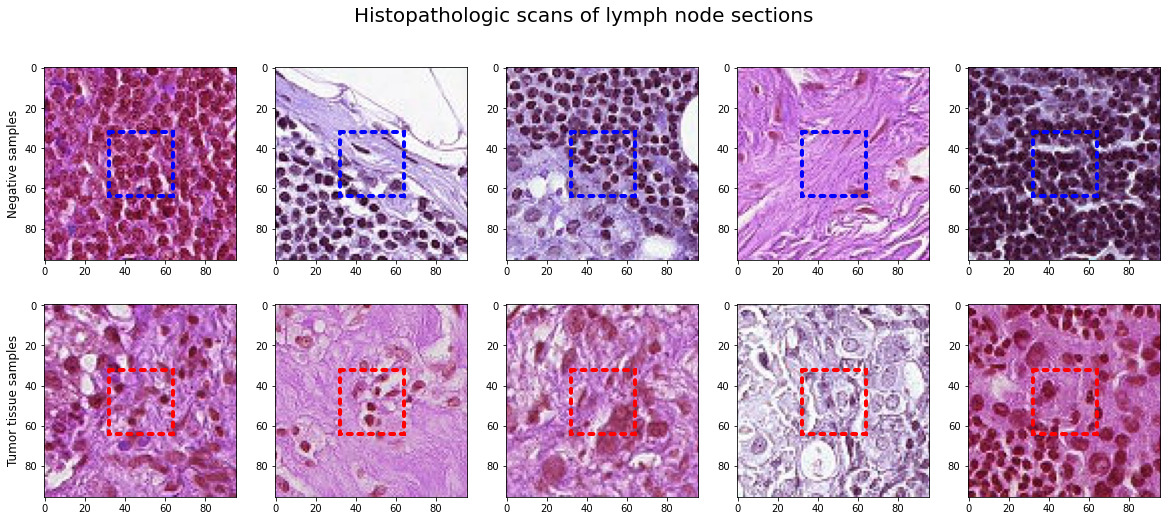

In [5]:
fig, ax = plt.subplots(2,5, figsize=(20,8))
fig.suptitle('Histopathologic scans of lymph node sections',fontsize=20)

# Negatives Group
for i, idx in enumerate(shuffled_data[shuffled_data['label'] == 0]['id'][:5]):
    path = os.path.join(train_path, idx)
    ax[0,i].imshow(readImage(path + '.tif'))
    
    # This will allow us to create a Rectangle patch to view
    box = patches.Rectangle((32,32),32,32,linewidth=4,edgecolor='b',facecolor='none', linestyle=':', capstyle='round')
    ax[0,i].add_patch(box)
ax[0,0].set_ylabel('Negative samples', size='large')

# Positives Group
for i, idx in enumerate(shuffled_data[shuffled_data['label'] == 1]['id'][:5]):
    path = os.path.join(train_path, idx)
    ax[1,i].imshow(readImage(path + '.tif'))
    
    # This will allow us to create a Rectangle patch to view
    box = patches.Rectangle((32,32),32,32,linewidth=4,edgecolor='r',facecolor='none', linestyle=':', capstyle='round')
    ax[1,i].add_patch(box)
ax[1,0].set_ylabel('Tumor tissue samples', size='large')

plt.show()

### Split the Data
We will read the csv file earlier to pandas dataframe, now we set index to id so we can perform our test/train split.

In [6]:
train_df = data.set_index('id')

train_names = train_df.index.values
train_labels = np.asarray(train_df['label'].values)

##### Getting our X and y values
We turn our images into numerical array data.

In [7]:
def get_X_and_y(path_str):

    data_add = []
    labels = []

    for index, row in data.iterrows():
        if row['id'] == 'id':
            continue
        img_file = str(os.path.join(path_str, row['id']) + '.tif')
        img_arr = np.array(Image.open(img_file))
        data_add.append(img_arr)
        labels.append(row['label'])

    data_im = np.array(data_add)      
    data_im = data_im.astype(dtype='uint8') 

    # Normalize our data
    data_im = data_im/255.0

    # Change our data dimensionality to 3D so that our algorithm can work properly
    x = data_im.reshape(len(data_im), -1)   

    y = np.array(labels)
    y = y.astype(dtype='uint8')  

    return x, y


# Call our "get_X_and_y" Function
X, y = get_X_and_y(train_path)  

#### Test/Train Split
We will split the X and y data into 20% Test and 80% Train data.

In [8]:
num_classes = 2  # binary: No Tumor (0) / Tumor Present (1)

input_shape = (96, 96, 3) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

X_train_input_shape = (len(X_train), 96, 96, 3)
y_train_input_shape = (len(y_train), 1)
X_test_input_shape = (len(X_test), 96, 96, 3)
y_test_input_shape = (len(y_test), 1)

X_train = np.reshape(X_train, X_train_input_shape)
y_train = np.reshape(y_train, y_train_input_shape)
X_test = np.reshape(X_test, X_test_input_shape)
y_test = np.reshape(y_test, y_test_input_shape)

###### Check Image Files & Labels along with their shape

In [9]:
print("Number of image files: {}".format(len(list(X_train)) + len(list(X_test))))
print("Number of image labels: {}".format(len(list(y_train)) + len(list(y_test))))

print(f"x_train shape: {X_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {X_test.shape} - y_test shape: {y_test.shape}")

Number of image files: 16000
Number of image labels: 16000
x_train shape: (12800, 96, 96, 3) - y_train shape: (12800, 1)
x_test shape: (3200, 96, 96, 3) - y_test shape: (3200, 1)


### Configure our Hyperparameters

In [10]:
learning_rate = 0.0001
weight_decay = 1e-6
batch_size = 64  # 256
num_epochs = 100
image_size = 72  # We'll resize input images to this size
patch_size = 6  # Specifying the size of the patches to be extracted from our input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Specifying the size of the transformer layers
transformer_layers = 8
mlp_head_units = [2048, 1024]  # Specifying the size of the dense layers of the final classifier

### Data Augmentation
This increases our sample size of images, which can in turn, increase our accuracy. We will use data augmentation techniques such as Normalization, Resizing, Random Flip, Random Rotation, and Random Zoom. This will change up the data we currently have to give us more image data to work with.

In [11]:
data_augmentation = kr.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="data_augmentation",
)

# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(X_train)

### Implement the Multilayer Perceptron (MLP)

In [12]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

### Implement Patch Creation as a Layer

In [13]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

### Implement the Patch Encoding Layer

In [14]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):  
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

### Build the Vision Transformer (ViT) Model

In [15]:
def create_vit_classifier():
    inputs = layers.Input(shape=input_shape)
    # Augment the data
    augmented = data_augmentation(inputs)  
    # Create our patches
    patches = Patches(patch_size)(augmented)
    # Encode our patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block
    for _ in range(transformer_layers):
        # Layer Normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a Multi-Head Attention layer
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip Connection 1
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer Normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip Connection 2
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add our Multi-Layer Perceptron
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify our outputs
    logits = layers.Dense(num_classes)(features)
    # Create the Keras Model
    model = kr.Model(inputs=inputs, outputs=logits)
    return model

> Note: `num_classes` was corrected from 100 (a leftover from the CIFAR-100 Keras ViT example) to 2 for this binary task, and the trivial top-5 metric was removed. Cells below were cleared and should be re-run against the dataset to regenerate outputs. The confusion-matrix counts and metric percentages in the markdown cells reflect the prior run and should be updated after re-running.

### Complie, Train, and Evaluate the ViT Model

We will now run our image data through our created ViT Model. We have decided to run 100 Epochs to save on the runtime of this model.

Model Optimizer: After attempting several model optimizers, such as Adam, we have concluded that the RMSprop Optimizer is best served for this dataset. Therefore, we have implemented that in our model using a learning rate (alpha) of 0.0001 and decay rate of 0.000001.

Model Compile: We configure the model with a Sparse Categorical Crossentropy loss and accuracy as the metric.

Checkpoint: We will save our model and weights in a checkpoint file to be accessed during Model Training.

History: We will save all aspects of our model, such as X_train, y_train, batch_size, and number of epochs, in our checkpoint filepath folder.

Load Weights: We will re-load our model weights from the checkpoint filepath folder.

In [ ]:
def run_experiment(model):
    optimizer = kr.optimizers.RMSprop(learning_rate=learning_rate, decay=weight_decay)  

    model.compile(
        optimizer=optimizer,
        loss=kr.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            kr.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )

    checkpoint_filepath = "./tmp/checkpoint2"
    checkpoint_callback = kr.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=X_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy = model.evaluate(X_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

### Model Summary

In [ ]:
print(vit_classifier.summary())
scores = vit_classifier.evaluate(X_test, y_test, verbose=1)
print()
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

### Confusion Matrix

In [ ]:
pred = vit_classifier.predict(X_test)

y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_test, y_pred , labels =[0,1]) 

show_cm = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=['No Tumor Present', 'Tumor Present'])
show_cm.plot()
plt.show()

##### Final Confusion Matrix Output:
True Positives (TP) = 1,208 Observations

True Negatives (TN) = 1,448 Observations

False Positives (FP) = 156 Observations

False Negatives (FN) = 388 Observations

### Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

##### Accuracy
We have decided to use Accuracy as the main evaluator of our ViT model’s performance. Accuracy represents the percent of total  correctly predicted data from our model. Our Test Accuracy is 83%, which shows that our model is predicting the large majority of our data correctly. 

##### Recall/Sensitivity
The average Recall/Sensitivity is 83%. This shows that out of all Actual Tumor Present classifications, 83% of the ones predicted as Tumor Present were correctly predicted. This Recall percenatage is high which shows that our model is strong. 

##### Precision
The average Precision is 84%. This shows that out of all the predictions we've made that are in the Tumor Present class, is 84% of those predictions were actually true. This Precision percentage is very large which shows that our model's performance is strong.

### Overall Conclusions
Since, our main evaluation metric of Accuracy is 83%, we will conclude that our ViT Model worked very well in correctly classifying our images as either *Tumor Present* or *No Tumor Present*. A major drawback of using the ViT Model on all 220K images was that it would've required a significantly higher amount of memory than what we have on our computers. Taking a smaller sample size of images to be processed (16K) allowed us to run the model within our memory constraints. The CNN Models previously ran in Kaggle, such as fast.ai did out perform ViT; however if we were able to process more images and run more epochs, we believe that we could be able to achieve an accuracy similar to or exceeding existing models. With the ability to save our model history and checkpoints, we can continually run epochs that would help to train our model to identify Metastatic Cancer effectively. Aside from the memory constraint, we also had a time constraint. Running each of our 100 epochs took 10 minutes. This is a really long time! Even though a significant amount of time was spent on just running and training the model using ViT, once the training of our ViT model is completed with an accuracy of over 90%, we can use our model on new images that would save doctors time for identifying Metastatic Cancer in the long run. 